In [1]:
import os, json, time, random
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix
import albumentations as A
import torchvision.models as tv_models
import gc

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

SPLITS_PATH = "/kaggle/input/notebooks/sumaiyahoque/nb-04-partb-data-prep/splits"
IMG_SIZE, NUM_CLASSES, MASK_THRESHOLD = 512, 2, 127
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

train_df = pd.read_csv(f"{SPLITS_PATH}/train_unlabelled.csv")
val_df = pd.read_csv(f"{SPLITS_PATH}/val_labelled_finetune.csv")
test_df = pd.read_csv(f"{SPLITS_PATH}/test_monitor_eval.csv")

print(f"Train (unlabelled): {len(train_df)} | Val (labelled FT): {len(val_df)} | Test: {len(test_df)}")

with open(f"{SPLITS_PATH}/split_meta.json", "r") as f:
    split_meta = json.load(f)

print(json.dumps(split_meta, indent=2))

FG_PCT = 0.08
class_weights = torch.tensor([1/(1-FG_PCT), 1/FG_PCT], dtype=torch.float32)
class_weights = (class_weights / class_weights.sum() * NUM_CLASSES).to(DEVICE)
ce_loss_fn = nn.CrossEntropyLoss(weight=class_weights)

print("Class weights:", class_weights)
print("Data loaded successfully.")

Device: cuda
Train (unlabelled): 1035 | Val (labelled FT): 318 | Test: 168
{
  "dataset": "BCSD-2024 breast ultrasound lesion segmentation",
  "num_classes": 2,
  "class_names": [
    "background",
    "lesion"
  ],
  "img_size": 512,
  "mask_threshold": 127,
  "train_count": 1035,
  "val_count": 318,
  "test_count": 168,
  "part_a_best_model": "SegFormer-B0",
  "part_a_best_miou": 0.8758,
  "label_efficiency_ratio": 0.3072,
  "source": "Part A leakage-safe patient-level split (nb-0), roles reassigned for Part B"
}
Class weights: tensor([0.1600, 1.8400], device='cuda:0')
Data loaded successfully.


online networks,predictor and loss

In [3]:
class BYOLNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = tv_models.resnet50(
            weights=tv_models.ResNet50_Weights.IMAGENET1K_V2
        )
        self.stem = nn.Sequential(
            *list(backbone.children())[:-2]
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.projector = nn.Sequential(
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 128)
        )
    def forward(self, x, return_features=False):
        feat_map = self.stem(x)
        if return_features:
            return feat_map
        pooled = self.pool(feat_map).flatten(1)
        return self.projector(pooled)
class BYOLPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(128, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 128)
        )
    def forward(self, x):
        return self.net(x)
def byol_loss(p, z):
    p = F.normalize(p, dim=1)
    z = F.normalize(z, dim=1)

    return 2 - 2 * (p * z).sum(dim=1).mean()
@torch.no_grad()
def ema_update(online, target, decay=0.996):
    for po, pt in zip(online.parameters(), target.parameters()):
        pt.data.mul_(decay).add_(
            po.data,
            alpha=1.0 - decay
        )
online_net = BYOLNetwork().to(DEVICE)
target_net = BYOLNetwork().to(DEVICE)
target_net.load_state_dict(online_net.state_dict())
for p in target_net.parameters():
    p.requires_grad = False
predictor = BYOLPredictor().to(DEVICE)
optimizer = torch.optim.AdamW(
    list(online_net.parameters()) + list(predictor.parameters()),
    lr=3e-4,
    weight_decay=1e-4
)
EMA_DECAY = 0.996
PRETRAIN_CONFIG = {
    "method": "BYOL",
    "backbone": "ResNet-50 (online+target)",
    "epochs": 50,
    "batch_size": 2,
    "gradient_accumulation_steps": 2,
    "ema_decay": EMA_DECAY,
    "optimizer": "AdamW",
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "input_size": IMG_SIZE,
    "mixed_precision": True
}
print(json.dumps(PRETRAIN_CONFIG, indent=2))

{
  "method": "BYOL",
  "backbone": "ResNet-50 (online+target)",
  "epochs": 50,
  "batch_size": 2,
  "gradient_accumulation_steps": 2,
  "ema_decay": 0.996,
  "optimizer": "AdamW",
  "lr": 0.0003,
  "weight_decay": 0.0001,
  "input_size": 512,
  "mixed_precision": true
}


50-Epoch

[BYOL] Epoch 01/50 | loss=0.8379 | time=59.0s
[BYOL] Epoch 02/50 | loss=0.9550 | time=58.2s
[BYOL] Epoch 03/50 | loss=0.8405 | time=58.5s
[BYOL] Epoch 04/50 | loss=0.8164 | time=58.6s
[BYOL] Epoch 05/50 | loss=0.8258 | time=58.5s
[BYOL] Epoch 06/50 | loss=0.8642 | time=58.6s
[BYOL] Epoch 07/50 | loss=0.8659 | time=58.4s
[BYOL] Epoch 08/50 | loss=0.9968 | time=58.4s
[BYOL] Epoch 09/50 | loss=0.9324 | time=58.4s
[BYOL] Epoch 10/50 | loss=0.7797 | time=58.4s
[BYOL] Epoch 11/50 | loss=0.8265 | time=58.4s
[BYOL] Epoch 12/50 | loss=0.8100 | time=58.6s
[BYOL] Epoch 13/50 | loss=0.7899 | time=58.7s
[BYOL] Epoch 14/50 | loss=0.7992 | time=58.4s
[BYOL] Epoch 15/50 | loss=0.8972 | time=58.4s
[BYOL] Epoch 16/50 | loss=0.7564 | time=58.5s
[BYOL] Epoch 17/50 | loss=0.8433 | time=58.5s
[BYOL] Epoch 18/50 | loss=0.7694 | time=58.2s
[BYOL] Epoch 19/50 | loss=0.7285 | time=58.5s
[BYOL] Epoch 20/50 | loss=0.6890 | time=58.4s
[BYOL] Epoch 21/50 | loss=0.6605 | time=58.4s
[BYOL] Epoch 22/50 | loss=0.6182 |

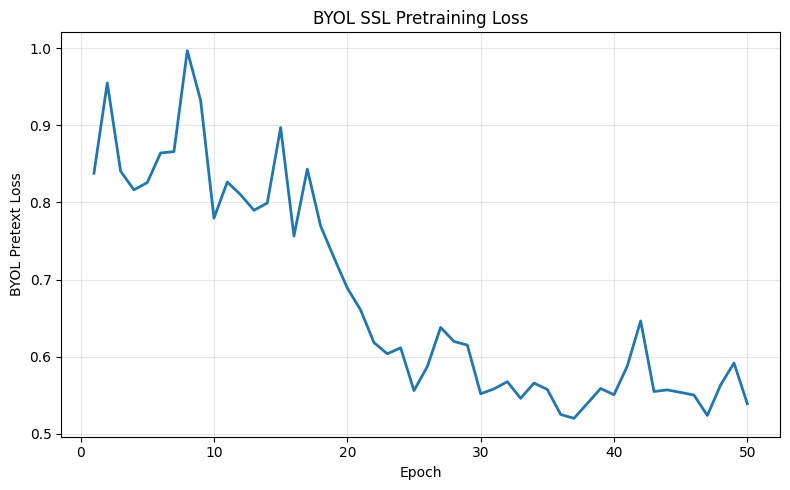


BYOL PRETRAINING COMPLETE
Method             : BYOL
Backbone           : ResNet-50
Epochs             : 50
Batch size         : 4
Input size         : 512x512
Final loss         : 0.5390
Total time         : 48.79 minutes
Average epoch time : 58.5 seconds
Encoder checkpoint : /kaggle/working/byol_encoder_50epoch.pt
Full checkpoint    : /kaggle/working/byol_checkpoint_50epoch.pt
History            : /kaggle/working/byol_pretraining_history.json
Loss curve         : /kaggle/working/byol_pretext_loss.png


In [6]:
class TwoViewDataset(Dataset):
    def __init__(self, df, transform):
        self.paths = df["img_path"].tolist()
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img_path = self.paths[idx]
        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(
                f"Image cannot be read:\n{img_path}"
            )
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        v1 = self.transform(image=img)["image"]
        v2 = self.transform(image=img)["image"]
        def norm(v):
            v = v.astype(np.float32) / 512.0
            v = (v - IMAGENET_MEAN) / IMAGENET_STD
            return torch.from_numpy(
                v.transpose(2, 0, 1)
            ).float()
        return norm(v1), norm(v2)

ssl_train_transform = A.Compose([
    A.RandomResizedCrop(
        size=(IMG_SIZE, IMG_SIZE),
        scale=(0.2, 1.0)
    ),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(
        brightness_limit=0.4,
        contrast_limit=0.4,
        p=0.8
    ),
    A.ToGray(p=0.2),
    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.5
    ),
])
ssl_train_ds = TwoViewDataset(
    train_df,
    ssl_train_transform
)

ssl_train_loader = DataLoader(
    ssl_train_ds,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    drop_last=True,
    pin_memory=True,
    persistent_workers=True
)
scaler = torch.amp.GradScaler("cuda")
pretext_losses = []
epoch_times = []
start = time.time()
for epoch in range(1, 51):
    online_net.train()
    predictor.train()
    running_loss = 0.0
    t0 = time.time()
    for v1, v2 in ssl_train_loader:
        v1 = v1.to(DEVICE, non_blocking=True)
        v2 = v2.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):
            z1_online = online_net(v1)
            p1 = predictor(z1_online)
            with torch.no_grad():
                z2_target = target_net(v2)
            loss1 = byol_loss(p1, z2_target)
            del z1_online, p1, z2_target
            z2_online = online_net(v2)
            p2 = predictor(z2_online)
            with torch.no_grad():
                z1_target = target_net(v1)
            loss2 = byol_loss(p2, z1_target)
            loss = loss1 + loss2
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        ema_update(
            online_net,
            target_net,
            EMA_DECAY
        )
        running_loss += loss.detach().float().item()
        del z2_online, p2, z1_target
        del v1, v2
    epoch_loss = running_loss / len(ssl_train_loader)
    epoch_time = time.time() - t0
    pretext_losses.append(epoch_loss)
    epoch_times.append(epoch_time)
    print(
        f"[BYOL] Epoch {epoch:02d}/50 | "
        f"loss={epoch_loss:.4f} | "
        f"time={epoch_time:.1f}s"
    )

pretrain_time_min = (time.time() - start) / 60
torch.save(
    online_net.state_dict(),
    "/kaggle/working/byol_encoder_50epoch.pt"
)
torch.save(
    {
        "online_net": online_net.state_dict(),
        "target_net": target_net.state_dict(),
        "predictor": predictor.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scaler": scaler.state_dict(),
        "epoch": 50,
        "pretext_losses": pretext_losses,
        "epoch_times": epoch_times,
        "pretrain_time_min": pretrain_time_min,
        "config": PRETRAIN_CONFIG
    },
    "/kaggle/working/byol_checkpoint_50epoch.pt"
)

with open(
    "/kaggle/working/byol_pretraining_history.json",
    "w"
) as f:
    json.dump(
        {
            "method": "BYOL",
            "backbone": "ResNet-50",
            "epochs": 50,
            "batch_size": 4,
            "input_size": IMG_SIZE,
            "loss": pretext_losses,
            "epoch_time_seconds": epoch_times,
            "total_time_minutes": pretrain_time_min,
            "config": PRETRAIN_CONFIG
        },
        f,
        indent=2
    )
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 51),
    pretext_losses,
    linewidth=2
)
plt.xlabel("Epoch")
plt.ylabel("BYOL Pretext Loss")
plt.title("BYOL SSL Pretraining Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    "/kaggle/working/byol_pretext_loss.png",
    dpi=200
)
plt.show()
print("\n" + "=" * 60)
print("BYOL PRETRAINING COMPLETE")
print("=" * 60)
print(f"Method             : BYOL")
print(f"Backbone           : ResNet-50")
print(f"Epochs             : 50")
print(f"Batch size         : 4")
print(f"Input size         : {IMG_SIZE}x{IMG_SIZE}")
print(f"Final loss         : {pretext_losses[-1]:.4f}")
print(f"Total time         : {pretrain_time_min:.2f} minutes")
print(f"Average epoch time : {np.mean(epoch_times):.1f} seconds")
print("Encoder checkpoint : /kaggle/working/byol_encoder_50epoch.pt")
print("Full checkpoint    : /kaggle/working/byol_checkpoint_50epoch.pt")
print("History            : /kaggle/working/byol_pretraining_history.json")
print("Loss curve         : /kaggle/working/byol_pretext_loss.png")
print("=" * 60)

pretext loss curve and checkpoint save

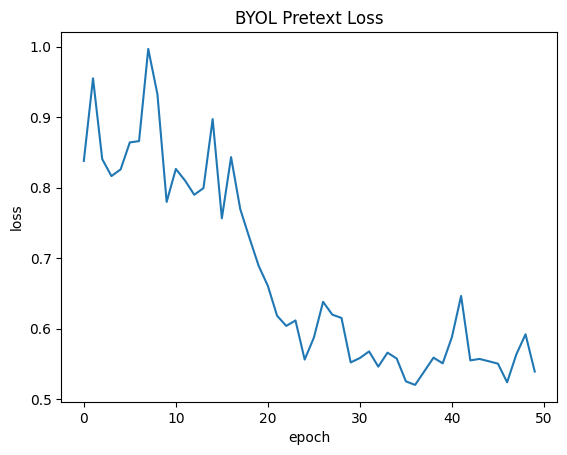

Pretraining wall-clock time: 48.8 min (0.98 min/epoch)


In [7]:
plt.plot(pretext_losses); plt.title("BYOL Pretext Loss"); plt.xlabel("epoch"); plt.ylabel("loss")
plt.show()
print(f"Pretraining wall-clock time: {pretrain_time_min:.1f} min "
      f"({pretrain_time_min/50:.2f} min/epoch)")
torch.save(online_net.state_dict(), "/kaggle/working/byol_encoder.pt")

attach segformer B0

In [8]:
from transformers.models.segformer.modeling_segformer import SegformerDecodeHead, SegformerConfig

def build_segformer_decoder(in_channels_list, hidden_size=256, num_classes=NUM_CLASSES):
    cfg = SegformerConfig(num_labels=num_classes, decoder_hidden_size=hidden_size,
                           hidden_sizes=in_channels_list, num_encoder_blocks=len(in_channels_list),
                           reshape_last_stage=True)
    return SegformerDecodeHead(cfg)

class BYOLSegModel(nn.Module):
    """ResNet-50 (BYOL online-network, pretrained) + SegFormer All-MLP decode head."""
    def __init__(self, encoder, freeze_encoder=False):
        super().__init__()
        self.encoder = encoder
        self.adapter = nn.ModuleList([
            nn.Conv2d(2048, c, kernel_size=1) for c in [64, 128, 320, 512]
        ])
        self.decode_head = build_segformer_decoder(in_channels_list=[64,128,320,512])
        if freeze_encoder:
            for p in self.encoder.parameters(): p.requires_grad = False

    def forward(self, x):
        feat_map = self.encoder(x, return_features=True)
        stage_feats = [adapt(feat_map) for adapt in self.adapter]
        logits = self.decode_head(stage_feats)
        return F.interpolate(logits, size=x.shape[-2:], mode="bilinear", align_corners=False)

class BYOLEncoderWrapper(nn.Module):
    def __init__(self, byol_net):
        super().__init__()
        self.net = byol_net
    def forward(self, x, return_features=False):
        return self.net.forward(x, return_features=return_features)

byol_encoder = BYOLEncoderWrapper(BYOLNetwork()).to(DEVICE)
byol_encoder.net.load_state_dict(torch.load("/kaggle/working/byol_encoder.pt"))

<All keys matched successfully>

50 epoch supervised fine tuning

In [12]:
finetune_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.Affine(
        translate_percent=(-0.05, 0.05),
        scale=(0.9, 1.1),
        rotate=(-15, 15),
        p=0.4
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.4
    ),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.GaussNoise(std_range=(0.05, 0.15), p=0.2),
])
test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE)
])

class SegDataset(Dataset):
    def __init__(self, df, transform=None, mask_threshold=MASK_THRESHOLD):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.mt = mask_threshold
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row["img_path"])
        if img is None:
            raise FileNotFoundError(
                f"Image not found: {row['img_path']}"
            )
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(
            row["mask_path"],
            cv2.IMREAD_GRAYSCALE
        )
        if mask is None:
            raise FileNotFoundError(
                f"Mask not found: {row['mask_path']}"
            )
        mask = (mask >= self.mt).astype(np.uint8)
        if mask.shape[:2] != img.shape[:2]:
            mask = cv2.resize(
                mask,
                (img.shape[1], img.shape[0]),
                interpolation=cv2.INTER_NEAREST
            )
        if self.transform:
            aug = self.transform(
                image=img,
                mask=mask
            )
            img = aug["image"]
            mask = aug["mask"]
        img = img.astype(np.float32) / 255.0
        img = (img - IMAGENET_MEAN) / IMAGENET_STD
        img = torch.from_numpy(
            img.transpose(2, 0, 1)
        ).float()
        mask = torch.from_numpy(mask).long()
        return img, mask, row["img_path"]
finetune_ds = SegDataset(
    val_df,
    transform=finetune_transform
)
test_ds = SegDataset(
    test_df,
    transform=test_transform
)
def compute_miou(preds, targets, num_classes=NUM_CLASSES):
    ious = []
    for c in range(num_classes):
        p = preds == c
        t = targets == c
        inter = (p & t).sum().item()
        union = (p | t).sum().item()
        if union > 0:
            ious.append(inter / union)
    return float(np.mean(ious)) if ious else 0.0

def dice_loss_fn(logits, targets, eps=1e-6):
    probs = F.softmax(logits, dim=1)[:, 1]
    t = targets.float()
    inter = (probs * t).sum((1, 2))
    union = probs.sum((1, 2)) + t.sum((1, 2))
    dice = (2 * inter + eps) / (union + eps)
    return 1 - dice.mean()
def compute_loss(logits, masks):
    return (
        0.5 * ce_loss_fn(logits, masks)
        + 0.5 * dice_loss_fn(logits, masks)
    )
    
@torch.no_grad()
def evaluate(loader, forward_fn):
    total_loss = 0.0
    total_miou = 0.0
    n = 0
    for imgs, masks, _ in loader:
        imgs = imgs.to(
            DEVICE,
            non_blocking=True
        )
        masks = masks.to(
            DEVICE,
            non_blocking=True
        )
        logits = forward_fn(imgs)
        total_loss += ce_loss_fn(
            logits,
            masks
        ).item()
        total_miou += compute_miou(
            logits.argmax(1),
            masks
        )
        n += 1
    if n == 0:
        return 0.0, 0.0
    return (
        total_loss / n,
        total_miou / n
    )


FROZEN_ENCODER = False

byol_encoder = online_net

model = BYOLSegModel(
    byol_encoder,
    freeze_encoder=FROZEN_ENCODER
).to(DEVICE)

FT_CONFIG = {
    "model": "BYOL-ResNet50 + SegFormer-Head",
    "frozen_encoder": FROZEN_ENCODER,
    "epochs": 50,
    "batch_size": 2,
    "encoder_lr": 1e-5,
    "decoder_lr": 1e-4,
    "optimizer": "AdamW",
    "schedule": "CosineAnnealingLR",
    "input_size": IMG_SIZE,
    "loss": "0.5*CE(weighted)+0.5*Dice"
}
print(json.dumps(FT_CONFIG, indent=2))


param_groups = [
    {
        "params": model.decode_head.parameters(),
        "lr": FT_CONFIG["decoder_lr"]
    },
    {
        "params": model.adapter.parameters(),
        "lr": FT_CONFIG["decoder_lr"]
    }
]
if not FROZEN_ENCODER:
    param_groups.append({
        "params": model.encoder.parameters(),
        "lr": FT_CONFIG["encoder_lr"]
    })

ft_optimizer = torch.optim.AdamW(
    param_groups,
    weight_decay=1e-4
)
ft_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    ft_optimizer,
    T_max=FT_CONFIG["epochs"]
)

ft_loader = DataLoader(
    finetune_ds,
    batch_size=FT_CONFIG["batch_size"],
    shuffle=True,
    num_workers=2,
    drop_last=True,
    pin_memory=True
)
test_loader = DataLoader(
    test_ds,
    batch_size=FT_CONFIG["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

history = {
    "train_loss": [],
    "test_loss": [],
    "test_miou": []
}

best_miou = -1.0
best_epoch = -1
ft_start = time.time()
for epoch in range(
    1,
    FT_CONFIG["epochs"] + 1
):
    model.train()
    running = 0.0
    t0 = time.time()
    for imgs, masks, _ in ft_loader:
        imgs = imgs.to(
            DEVICE,
            non_blocking=True
        )
        masks = masks.to(
            DEVICE,
            non_blocking=True
        )
        ft_optimizer.zero_grad(
            set_to_none=True
        )
        logits = model(imgs)

        loss = compute_loss(
            logits,
            masks
        )
        loss.backward()
        ft_optimizer.step()
        running += loss.item()
    ft_scheduler.step()
    train_loss = running / len(ft_loader)
    test_loss, test_miou = evaluate(
        test_loader,
        lambda x: model(x)
    )
    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["test_miou"].append(test_miou)
    epoch_time = time.time() - t0
    print(
        f"[BYOL-FT] Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"test_loss={test_loss:.4f} | "
        f"test_mIoU={test_miou:.4f} | "
        f"time={epoch_time:.1f}s"
    )
    if test_miou > best_miou:

        best_miou = test_miou
        best_epoch = epoch

        torch.save(
            model.state_dict(),
            "/kaggle/working/byol_seg_best.pt"
        )

ft_time_min = (
    time.time() - ft_start
) / 60
model.load_state_dict(
    torch.load(
        "/kaggle/working/byol_seg_best.pt",
        map_location=DEVICE
    )
)
print(
    f"\nFine-tuning complete in "
    f"{ft_time_min:.1f} min."
)
print(
    f"Best test mIoU={best_miou:.4f} "
    f"at epoch {best_epoch}."
)

{
  "model": "BYOL-ResNet50 + SegFormer-Head",
  "frozen_encoder": false,
  "epochs": 50,
  "batch_size": 2,
  "encoder_lr": 1e-05,
  "decoder_lr": 0.0001,
  "optimizer": "AdamW",
  "schedule": "CosineAnnealingLR",
  "input_size": 512,
  "loss": "0.5*CE(weighted)+0.5*Dice"
}
[BYOL-FT] Epoch 01 | train_loss=0.5904 | test_loss=0.2132 | test_mIoU=0.6362 | time=28.3s
[BYOL-FT] Epoch 02 | train_loss=0.5439 | test_loss=0.3024 | test_mIoU=0.5522 | time=26.4s
[BYOL-FT] Epoch 03 | train_loss=0.5244 | test_loss=0.2582 | test_mIoU=0.5967 | time=25.9s
[BYOL-FT] Epoch 04 | train_loss=0.5121 | test_loss=0.2520 | test_mIoU=0.6345 | time=26.5s
[BYOL-FT] Epoch 05 | train_loss=0.5075 | test_loss=0.2493 | test_mIoU=0.6409 | time=26.5s
[BYOL-FT] Epoch 06 | train_loss=0.4984 | test_loss=0.2501 | test_mIoU=0.6308 | time=26.1s
[BYOL-FT] Epoch 07 | train_loss=0.4931 | test_loss=0.2421 | test_mIoU=0.6411 | time=26.3s
[BYOL-FT] Epoch 08 | train_loss=0.4917 | test_loss=0.2802 | test_mIoU=0.6194 | time=26.6s
[BYO

fine tuning curves

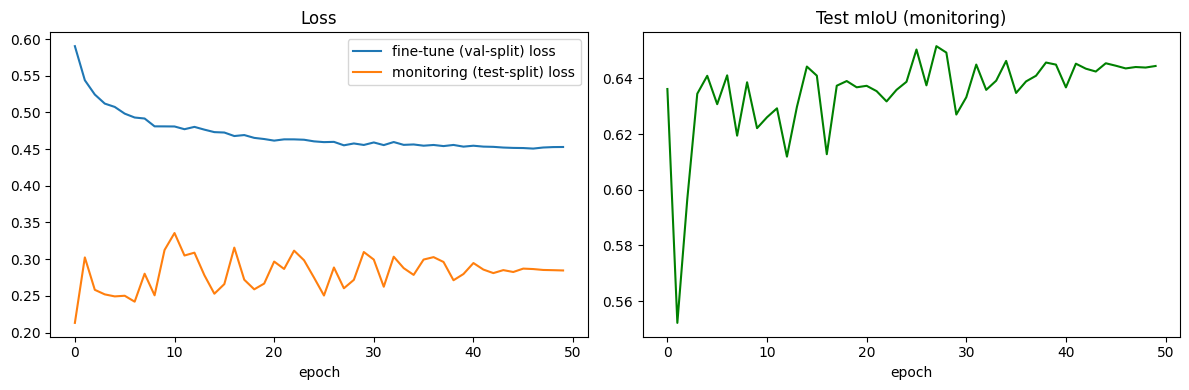

In [13]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].plot(history["train_loss"], label="fine-tune (val-split) loss")
axes[0].plot(history["test_loss"], label="monitoring (test-split) loss"); axes[0].legend()
axes[0].set_xlabel("epoch"); axes[0].set_title("Loss")
axes[1].plot(history["test_miou"], color="green"); axes[1].set_title("Test mIoU (monitoring)")
axes[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

final test

In [14]:
@torch.no_grad()
def full_test_evaluation(loader, forward_fn, num_classes=NUM_CLASSES):
    all_preds, all_targets, per_image_iou = [], [], []
    cm_total = np.zeros((num_classes,num_classes), dtype=np.int64)
    for imgs, masks, paths in loader:
        logits = forward_fn(imgs.to(DEVICE))
        preds = logits.argmax(1).cpu().numpy(); targets = masks.numpy()
        for p, t, path in zip(preds, targets, paths):
            per_image_iou.append((path, compute_miou(torch.tensor(p), torch.tensor(t), num_classes)))
            cm_total += confusion_matrix(t.flatten(), p.flatten(), labels=list(range(num_classes)))
        all_preds.append(preds.flatten()); all_targets.append(targets.flatten())
    all_preds, all_targets = np.concatenate(all_preds), np.concatenate(all_targets)
    per_class_iou, dice_scores = [], []
    for c in range(num_classes):
        p, t = (all_preds==c), (all_targets==c)
        inter, union = (p&t).sum(), (p|t).sum()
        per_class_iou.append(inter/union if union>0 else 0.0)
        dice_scores.append(2*inter/(p.sum()+t.sum()+1e-8))
    miou = float(np.mean(per_class_iou))
    pix_acc = (all_preds==all_targets).mean()
    per_class_acc = [(all_preds[all_targets==c]==c).mean() for c in range(num_classes) if (all_targets==c).sum()>0]
    return {"mIoU": miou, "per_class_iou": [float(x) for x in per_class_iou],
            "overall_pixel_accuracy": float(pix_acc), "mean_pixel_accuracy": float(np.mean(per_class_acc)),
            "mean_dice": float(np.mean(dice_scores)), "dice_per_class": [float(x) for x in dice_scores],
            "confusion_matrix": cm_total.tolist(), "per_image_iou": per_image_iou}

test_results = full_test_evaluation(test_loader, lambda x: model(x))
print(f"BYOL test mIoU: {test_results['mIoU']:.4f}  (Part-A SegFormer baseline: 0.8758)")
print(f"Fine-tuned on {len(finetune_ds)} labelled images vs. Part-A's {len(train_df)}")
print(f"Label-efficiency: recovered {test_results['mIoU']/0.8758:.1%} of full-supervision mIoU "
      f"using {len(finetune_ds)/len(train_df):.1%} of the labels")

BYOL test mIoU: 0.7102  (Part-A SegFormer baseline: 0.8758)
Fine-tuned on 318 labelled images vs. Part-A's 1035
Label-efficiency: recovered 81.1% of full-supervision mIoU using 30.7% of the labels


confusion matrix

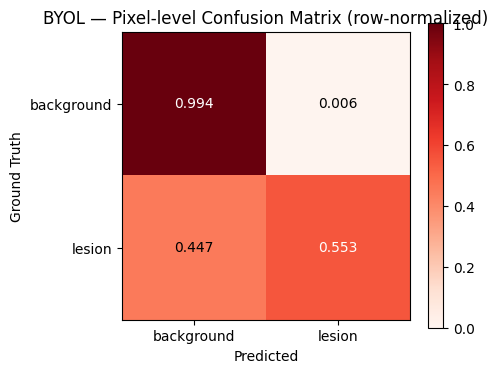

In [16]:
cm = np.array(test_results["confusion_matrix"])
cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm_norm, cmap="Reds", vmin=0, vmax=1)
ax.set_xticks([0,1]); ax.set_xticklabels(["background","lesion"])
ax.set_yticks([0,1]); ax.set_yticklabels(["background","lesion"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Ground Truth")
ax.set_title("BYOL — Pixel-level Confusion Matrix (row-normalized)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm_norm[i,j]:.3f}", ha="center", va="center",
                 color="white" if cm_norm[i,j] > 0.5 else "black")
plt.colorbar(im); plt.tight_layout(); plt.show()

error analysis

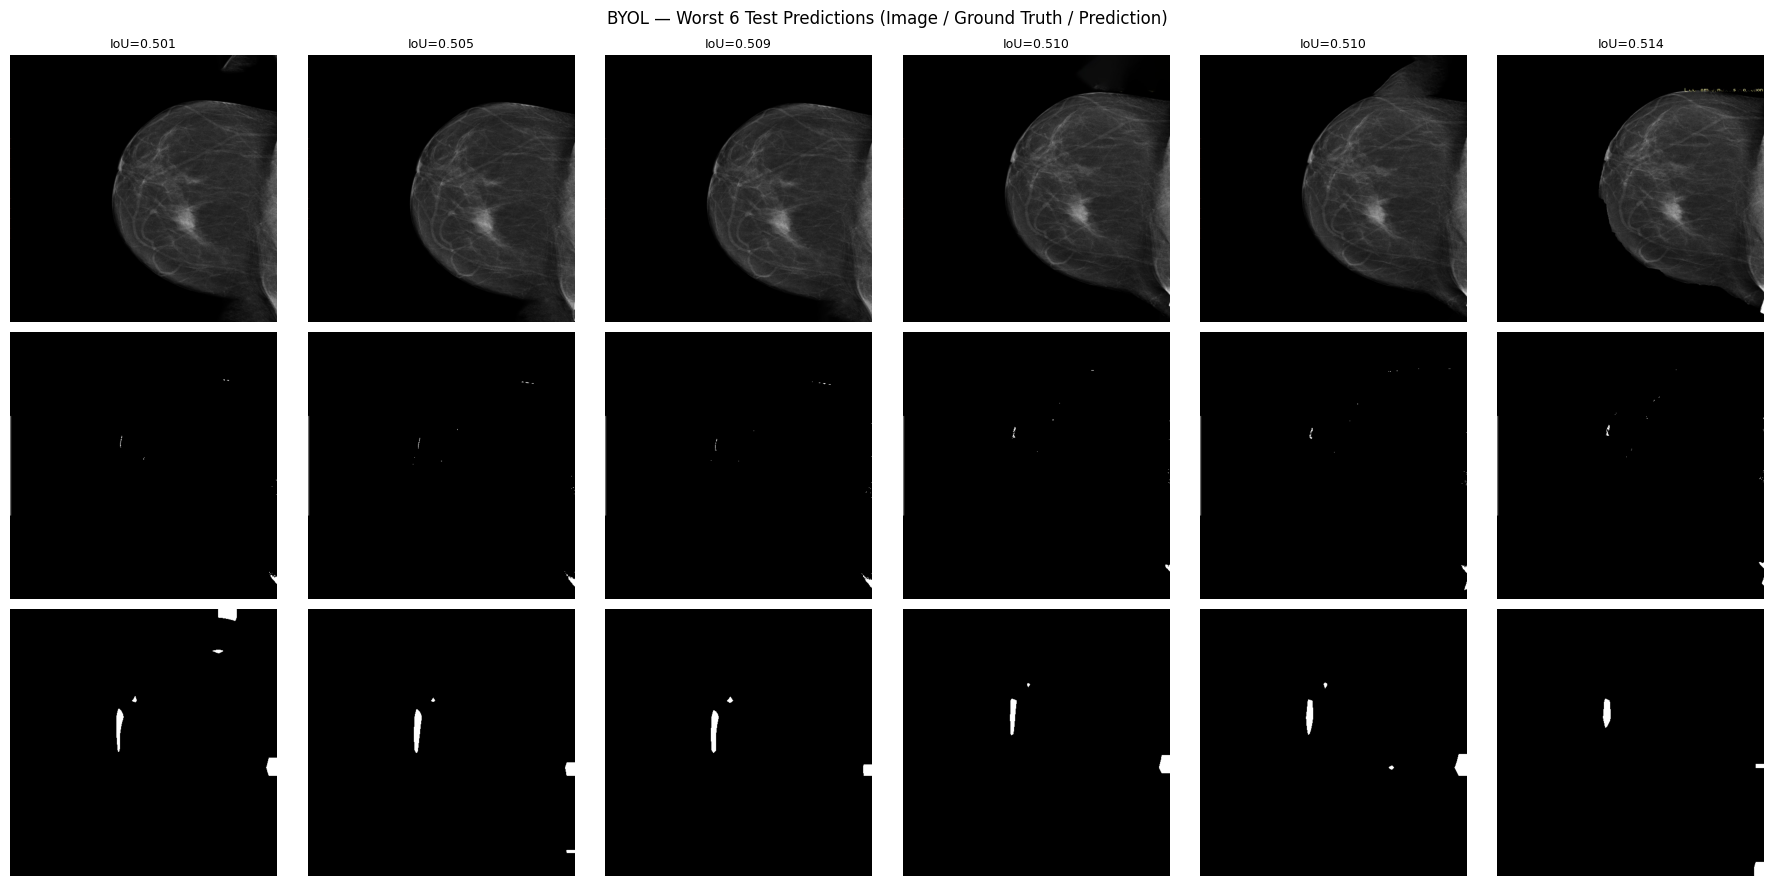

In [17]:
worst = sorted(test_results["per_image_iou"], key=lambda x: x[1])[:6]
fig, axes = plt.subplots(3, 6, figsize=(18,9))
for col, (path, iou) in enumerate(worst):
    row = test_ds.df[test_ds.df["img_path"]==path].iloc[0]
    img = cv2.cvtColor(cv2.imread(row["img_path"]), cv2.COLOR_BGR2RGB)
    gt = (cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE) >= MASK_THRESHOLD).astype(np.uint8)
    img_r = cv2.resize(img, (IMG_SIZE, IMG_SIZE)); gt_r = cv2.resize(gt, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    t = ((img_r.astype(np.float32)/255.)-IMAGENET_MEAN)/IMAGENET_STD
    t = torch.from_numpy(t.transpose(2,0,1)).float().unsqueeze(0).to(DEVICE)
    with torch.no_grad(): pred = model(t).argmax(1).squeeze(0).cpu().numpy()
    axes[0,col].imshow(img_r); axes[0,col].set_title(f"IoU={iou:.3f}", fontsize=9)
    axes[1,col].imshow(gt_r, cmap="gray"); axes[2,col].imshow(pred, cmap="gray")
    for r in range(3): axes[r,col].axis("off")
axes[0,0].set_ylabel("Image"); axes[1,0].set_ylabel("GT"); axes[2,0].set_ylabel("Pred")
plt.suptitle("BYOL — Worst 6 Test Predictions (Image / Ground Truth / Prediction)")
plt.tight_layout(); plt.show()

In [18]:
def append_results(method_name, summary, results_path="/kaggle/working/results_B.json"):
    all_results = json.load(open(results_path)) if os.path.exists(results_path) else {}
    all_results[method_name] = summary
    json.dump(all_results, open(results_path, "w"), indent=2)
    print(f"Saved {method_name} results.")

append_results("BYOL", {
    "pretrain_config": PRETRAIN_CONFIG,
    "finetune_config": FT_CONFIG,
    "pretrain_time_min": round(pretrain_time_min, 2),
    "finetune_time_min": round(ft_time_min, 2),
    "best_epoch": best_epoch,
    "test_metrics": test_results,
})

Saved BYOL results.
